In [13]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv('data.csv')

In [15]:
df.head(10)

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647
5,-0.889889,-1.580945,-0.422793,-77.897356
6,-2.685109,0.018421,1.722669,-75.231606
7,0.663188,0.185268,-1.883424,-57.492711
8,0.319196,-2.983970,-1.515216,-54.176286
9,-0.348368,-1.811019,0.746892,29.469835


In [16]:
X = df.iloc[:,0:3].values
y = df.iloc[:,-1].values

### ****Ab Mai Yaha pe Linear Reg apply karunga****

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [18]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [19]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[73.75, 0.82,54.91]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.8708
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[13.04,12.04,11.33]"


### ****Residual****

In [20]:
y_pred = model.predict(X_test)
residual = y_test - y_pred

## ****1- Linear RelationShip****

### ****Ab Mai Yaha pe Sabke liye Scatter plaot Banunga****

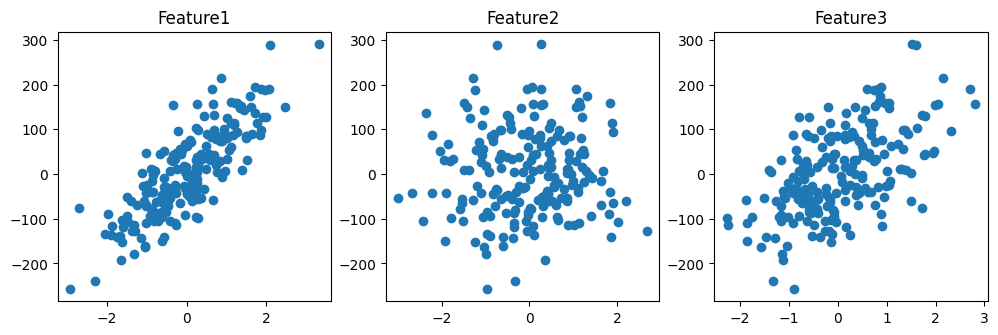

In [21]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols = 3, figsize = (12,3.5))

ax1.scatter(df['feature1'],df['target'])
ax1.set_title("Feature1")

ax2.scatter(df['feature2'], df['target'])
ax2.set_title('Feature2')

ax3.scatter(df['feature3'], df['target'])
ax3.set_title('Feature3')

plt.show()


* **Feature1:** Strong Positive Linear relationship hai (points seedhe upar ja rahe hain).
* **Feature2:** No Linear relationship hai (points random cloud ki tarah bikhre hain).
* **Feature3:** Moderate Positive Linear relationship hai (points failte hue upar ki taraf ja rahe hain).

___

## ******2- Multicollinearity******

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Seedha X_train pass karo bina .values ke
vif = []
for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))

# Output dekhne ke liye
print("VIF Values:", vif)

VIF Values: [np.float64(1.0019003237651773), np.float64(1.0150610597681176), np.float64(1.0132115779988566)]


In [23]:
pd.DataFrame({'vif': vif}, index=df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.0019,1.015061,1.013212


## ****Another Technique****

<Axes: >

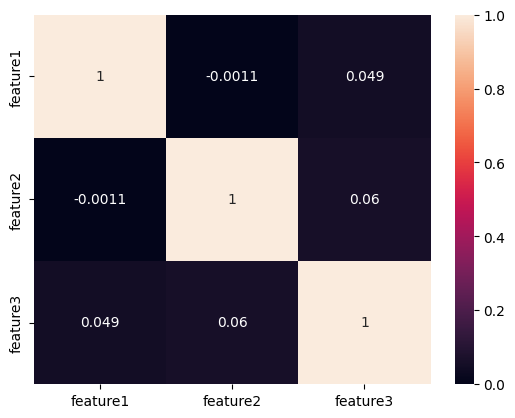

In [24]:
sns.heatmap(df.iloc[:,0:3].corr(),annot=True)


___